In [1]:
import numpy as np 
import h5py
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import sys
import re

# import some tools from the wider directory
sys.path.insert(0, os.path.abspath('..'))   # adds fastersimulation/ to the path
import utilities

In [2]:
# path relative to where you run this script
path = '../results/time_step_sweep/'
def _parse_folder(folder_name):
    """Robustly extract ff_dt and mr_dt from folder names like ffdt_0.01_mrdt_0.02."""
    # Matches anything until the next underscore to handle floating point precision artifacts
    m = re.search(r'ffdt_([^_]+)_mrdt_([^_]+)', folder_name)
    if m:
        try:
            return float(m.group(1)), float(m.group(2))
        except ValueError:
            pass
    return -1.0, -1.0
# ── Discover all ffdt_* folders ──────────
sweep_dirs = [
    d for d in os.listdir(path)
    if os.path.isdir(os.path.join(path, d)) and d.startswith('ffdt_')
]
# Sort hierarchically by FF DT, then Mirror DT
sweep_dirs.sort(key=lambda d: _parse_folder(d))
out_path = os.path.join(path, 'combined_dt_sweep.h5')
missing  = []
print(f"Collating {len(sweep_dirs)} folders into {out_path}...")
with h5py.File(out_path, 'w') as out_f:
    for folder in sweep_dirs:
        ff_dt, mr_dt = _parse_folder(folder)
        
        if ff_dt < 0:
            print(f"  [SKIP] {folder} — could not parse DT values")
            continue
        h5_path = os.path.join(path, folder, 'mirror_states.h5')
        if not os.path.isfile(h5_path):
            print(f"  [SKIP] ff_dt={ff_dt}, mr_dt={mr_dt} — mirror_states.h5 not found")
            missing.append(folder)
            continue
            
        # Create a unique group name for this configuration in the H5 file
        group_name = f'ffdt_{ff_dt}_mrdt_{mr_dt}'
        
        with h5py.File(h5_path, 'r') as src_f:
            # Copy all groups and datasets
            src_f.copy('/', out_f, name=group_name)
            
        print(f"  [OK]   {folder}  →  {group_name}/")
print(f"\nSaved combined file → {out_path}")
if missing:
    print(f"WARNING: {len(missing)} folders had no mirror_states.h5 file!")

Collating 8 folders into ../results/time_step_sweep/combined_dt_sweep.h5...
  [SKIP] ff_dt=0.005, mr_dt=0.1 — mirror_states.h5 not found
  [OK]   ffdt_0.01_mrdt_0.1  →  ffdt_0.01_mrdt_0.1/
  [OK]   ffdt_0.02_mrdt_0.1  →  ffdt_0.02_mrdt_0.1/
  [OK]   ffdt_0.05_mrdt_0.1  →  ffdt_0.05_mrdt_0.1/
  [OK]   ffdt_0.1_mrdt_0.1  →  ffdt_0.1_mrdt_0.1/
  [OK]   ffdt_0.2_mrdt_0.1  →  ffdt_0.2_mrdt_0.1/
  [OK]   ffdt_0.5_mrdt_0.1  →  ffdt_0.5_mrdt_0.1/
  [OK]   ffdt_1.0_mrdt_0.1  →  ffdt_1.0_mrdt_0.1/

Saved combined file → ../results/time_step_sweep/combined_dt_sweep.h5


In [3]:
def _h5_tree(item, indent=0, max_seg=2):
    """Recursively print HDF5 tree, collapsing repeated segment_ groups."""
    prefix = "  " * indent
    
    if isinstance(item, h5py.File):
        print(f"{prefix}/ (attrs: {dict(item.attrs)})")
        
        # Helper to extract (area, focal) from "app_113.10_focal_5000.0" for sorting
        def _parse_grp(x):
            if not x.startswith('app_'): return (-1.0, -1.0)
            parts = x.split('_')
            try:
                # Expecting: app, AREA, focal, FOCAL
                return (float(parts[1]), float(parts[3]))
            except (IndexError, ValueError):
                return (-1.0, -1.0)
                
        children = sorted(item.keys(), key=_parse_grp)
        for k in children:
            _h5_tree(item[k], indent+1, max_seg)
            
    elif isinstance(item, h5py.Group):
        name = item.name.split('/')[-1]
        children = list(item.keys())
        seg_keys = sorted([k for k in children if k.startswith('segment_')],
                          key=lambda x: int(x.split('_')[1]))
        other_keys = [k for k in children if not k.startswith('segment_')]
        print(f"{prefix}┣ {name}/")
        
        for k in sorted(other_keys):
            _h5_tree(item[k], indent+1, max_seg)
            
        # Show first N segments then summarise the rest
        for k in seg_keys[:max_seg]:
            _h5_tree(item[k], indent+1, max_seg)
        if len(seg_keys) > max_seg:
            print(f"{'  '*(indent+1)}┆ ... ({len(seg_keys) - max_seg} more segment_ groups)")
            
    elif isinstance(item, h5py.Dataset):
        name = item.name.split('/')[-1]
        dtype = item.dtype
        shape = item.shape
        print(f"{prefix}┃  {name:30s}  {str(shape):20s}  {dtype}")

# ── Execute the Tree Printer ──
#out_path = '../results/ring_vs_focal_sweep/combined_sweep.h5'

with h5py.File(out_path, 'r') as f:
    _h5_tree(f, max_seg=1)   # show only 1 segment per run to keep it readable


/ (attrs: {})
  ┣ ffdt_0.01_mrdt_0.1/
    ┣ config/
      ┃  star_vector                     (3,)                  float64
    ┃  mirror_time                     (9000,)               float64
    ┃  phase                           (1425021,)            object
    ┃  r_app_eci                       (1425021, 3)          float64
    ┃  r_det_eci                       (1425021, 3)          float64
    ┃  rel_pos_B                       (9000, 3)             float64
    ┃  rel_sigma_B                     (1425021, 3)          float64
    ┃  sigma_app_star                  (1425021, 3)          float64
    ┃  sigma_det_star                  (1425021, 3)          float64
    ┃  time                            (1425021,)            float64
    ┣ segment_0/
      ┃  desired_mirror_actuation        (9000, 6)             float64
      ┃  mirror_actuation                (9000, 6)             float64
      ┃  point_on_det_plane              (9000, 2)             float64
      ┃  position          

In [4]:
with h5py.File(out_path, 'r') as src_f:
    
    # Helper to extract (area, focal) from group names for perfect sorting
    def _parse_grp(x):
        if not x.startswith('ffdt_'): return (-1.0, -1.0)
        parts = x.split('_')
        try:
            # Expected format: app, AREA, focal, FOCAL
            return (float(parts[1]), float(parts[3]))
        except (IndexError, ValueError):
            return (-1.0, -1.0)
            
    # Get all the exact group keys directly from the file, perfectly sorted!
    # These strings will be exactly like: "app_113.10_focal_5000.0"
    group_keys = sorted([k for k in src_f.keys() if k.startswith('ffdt_')], key=_parse_grp)
    num_runs = len(group_keys)
    print(f'Total number of simulation runs = {num_runs}')

    # Read segment count dynamically from the very first group
    first_group = group_keys[0]
    segs = sorted([int(k.split('_')[1]) for k in src_f[first_group].keys() if k.startswith('segment_')])
    num_of_segs = len(segs)
    print(f'Number of segments = {num_of_segs}')

    # Initialize lists to hold the varying-length arrays
    phase = []
    full_times = []
    eng_times = []
    
    # Parameters for the new grid (Area and Focal Length)
    ffdt_vals = []
    mrdt_vals = []
    
    # Translation (Position) variables
    r_app_eci = []
    r_det_eci = []
    rel_pos_B = []
    
    # Rotation (Attitude) variables
    sigma_app_star = []
    sigma_det_star = []
    rel_sigma_B = []
    
    # Segment-specific variables
    mirror_actuation = []
    desired_mirror_actuation = []
    point_on_det_plane = []

    # Loop through the exact group strings
    for group in group_keys:
        
        # Keep track of the physical variables for this run
        ffdt, mrdt = _parse_grp(group)
        ffdt_vals.append(ffdt)
        mrdt_vals.append(mrdt)
        
        # Depending on how the string array was saved, it might be stored as byte strings
        # .astype(str) ensures it converts b'fine' back to a normal python string 'fine'
        phase.append(src_f[group]['phase'][:].astype(str))
        
        # Extract the time arrays for this specific run
        full_times.append(src_f[group]['time'][:])
        eng_times.append(src_f[group]['mirror_time'][:])
        
        # Append Translation (Position) arrays
        r_app_eci.append(src_f[group]['r_app_eci'][:])
        r_det_eci.append(src_f[group]['r_det_eci'][:])
        rel_pos_B.append(src_f[group]['rel_pos_B'][:])
        
        # Append Rotation (Attitude MRP) arrays
        sigma_app_star.append(src_f[group]['sigma_app_star'][:])
        sigma_det_star.append(src_f[group]['sigma_det_star'][:])
        rel_sigma_B.append(src_f[group]['rel_sigma_B'][:])
        
        # Gather all segments into temporary lists for this specific run
        ma_segments = []
        dma_segments = []
        podp_segments = []
        
        for s in segs:
            ma_segments.append(src_f[group][f'segment_{s}']['mirror_actuation'][:])
            dma_segments.append(src_f[group][f'segment_{s}']['desired_mirror_actuation'][:])
            podp_segments.append(src_f[group][f'segment_{s}']['point_on_det_plane'][:])
            
        # Append the nested list of segments to the master lists
        mirror_actuation.append(ma_segments)
        desired_mirror_actuation.append(dma_segments)
        point_on_det_plane.append(podp_segments)

print("Data successfully loaded into lists!")


Total number of simulation runs = 7
Number of segments = 7
Data successfully loaded into lists!


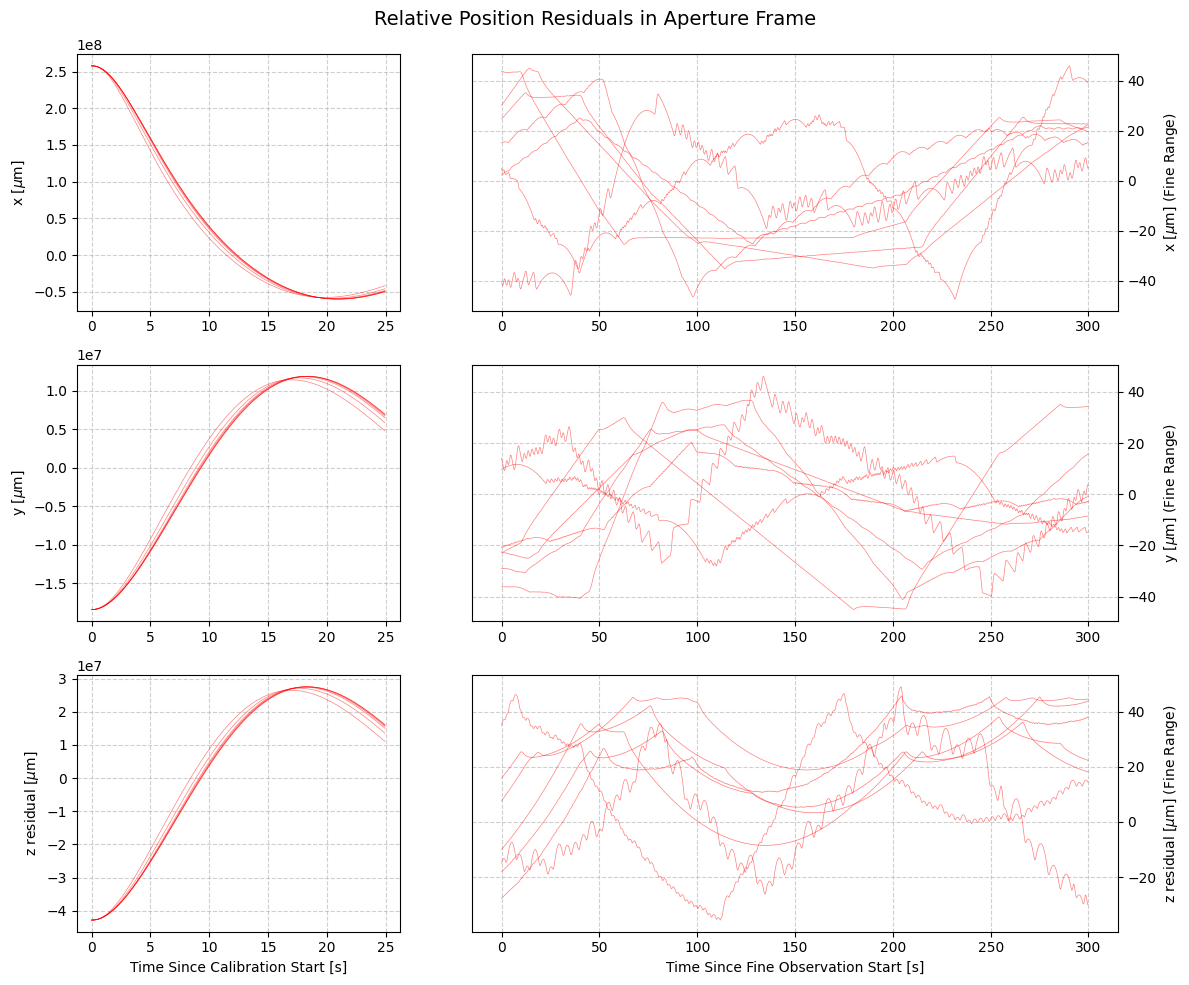

In [5]:
coord_letter = ['x', 'y', 'z']
# Dynamically scale opacity based on the massive 3D grid size
#alpha_lines = 1 - 0.5**(1/num_runs)
alpha_lines = 0.5


# 1. Set up the figure and GridSpec 
rel_pos_fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(3, 2, width_ratios=[1, 2], figure=rel_pos_fig)
rel_pos_fig.suptitle('Relative Position Residuals in Aperture Frame', fontsize=14)

rel_pos_ax = []

for row in range(3):
    ax_cal = rel_pos_fig.add_subplot(gs[row, 0])
    
    # We turn off sharey=ax_cal so the Fine plots can uniquely zoom in on their tighter tolerance!
    ax_fine = rel_pos_fig.add_subplot(gs[row, 1])
    
    # Move the fine y-ticks to the right side so they don't overlap the LHS graphs!
    ax_fine.yaxis.tick_right()
    ax_fine.yaxis.set_label_position("right")
    
    rel_pos_ax.append((ax_cal, ax_fine))

rel_pos_ax[2][0].set_xlabel('Time Since Calibration Start [s]')
rel_pos_ax[2][1].set_xlabel('Time Since Fine Observation Start [s]')

for coord in range(len(coord_letter)):
    label = f'{coord_letter[coord]}'
    if coord == 2:
        label = 'z residual' # Clarify it's a residual
        
    rel_pos_ax[coord][0].set_ylabel(f'{label} [$\mu$m]')
    rel_pos_ax[coord][1].set_ylabel(f'{label} [$\mu$m] (Fine Range)')
    
    # Add grid lines to all subplots
    rel_pos_ax[coord][0].grid(True, linestyle='--', alpha=0.6)
    rel_pos_ax[coord][1].grid(True, linestyle='--', alpha=0.6)

# 2. Plot all simulation sweeps
for i in range(num_runs):
    t_eng = eng_times[i]
    rel = rel_pos_B[i]
    #current_focal = focal_vals[i] # Get the target focal length for this specific run
    current_focal = 5000
    
    # EXPLICITLY find start/end times of each phase for THIS run
    cal_idx  = np.where(phase[i] == 'Calibration')[0]
    fine_idx = np.where(phase[i] == 'Fine Observation')[0]
    
    # Mask exactly the 'Calibration' windows
    if len(cal_idx) > 0:
        cal_start, cal_end = full_times[i][cal_idx[0]], full_times[i][cal_idx[-1]]
        cal_mask = (t_eng >= cal_start) & (t_eng <= cal_end)
    else:
        cal_mask = np.zeros_like(t_eng, dtype=bool)
        
    # Mask exactly the 'Fine Observation' windows
    if len(fine_idx) > 0:
        fine_start, fine_end = full_times[i][fine_idx[0]], full_times[i][fine_idx[-1]]
        fine_mask = (t_eng >= fine_start) & (t_eng <= fine_end)
    else:
        fine_mask = np.zeros_like(t_eng, dtype=bool)

    # Slice the arrays using the masks
    cal_t       = t_eng[cal_mask]
    cal_rel     = rel[cal_mask]
    
    fine_t      = t_eng[fine_mask]
    fine_rel    = rel[fine_mask]

    cal_t       = cal_t[:250]
    cal_rel     = cal_rel[:250]

    # Shift times so both phases start exactly at t=0
    if len(cal_t) > 0:
        cal_t = cal_t - cal_t[0]
    if len(fine_t) > 0:
        fine_t = fine_t - fine_t[0]

    for coord in range(len(coord_letter)):
        # Calculate values to plot
        cal_vals = cal_rel[:, coord]
        fine_vals = fine_rel[:, coord]
        
        # Subtract focal length if plotting the Z-axis to show residuals
        if coord == 2:
            cal_vals = cal_vals - current_focal
            fine_vals = fine_vals - current_focal

        # Plot Calibrating Phase on LHS (Multiply by 1e6 for micrometers)
        if len(cal_t) > 0:
            rel_pos_ax[coord][0].plot(cal_t, cal_vals * 1e6, linewidth=0.5, color='red', alpha=alpha_lines)
            
        # Plot Fine Observation Phase on RHS (Multiply by 1e6 for micrometers)
        if len(fine_t) > 0:
            rel_pos_ax[coord][1].plot(fine_t, fine_vals * 1e6, linewidth=0.5, color='red', alpha=alpha_lines)

plt.tight_layout()
plt.subplots_adjust(wspace=0.15) 
plt.show()


unique ffdt [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0]
unique mrdt [0.1]
Plotting 7 runs on a 7x1 grid.
Nodes successfully filled: 7


/tmp/SLURM_7563290/ipykernel_1006412/786668827.py:46: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(grid * 1e6, origin='lower', aspect='auto',


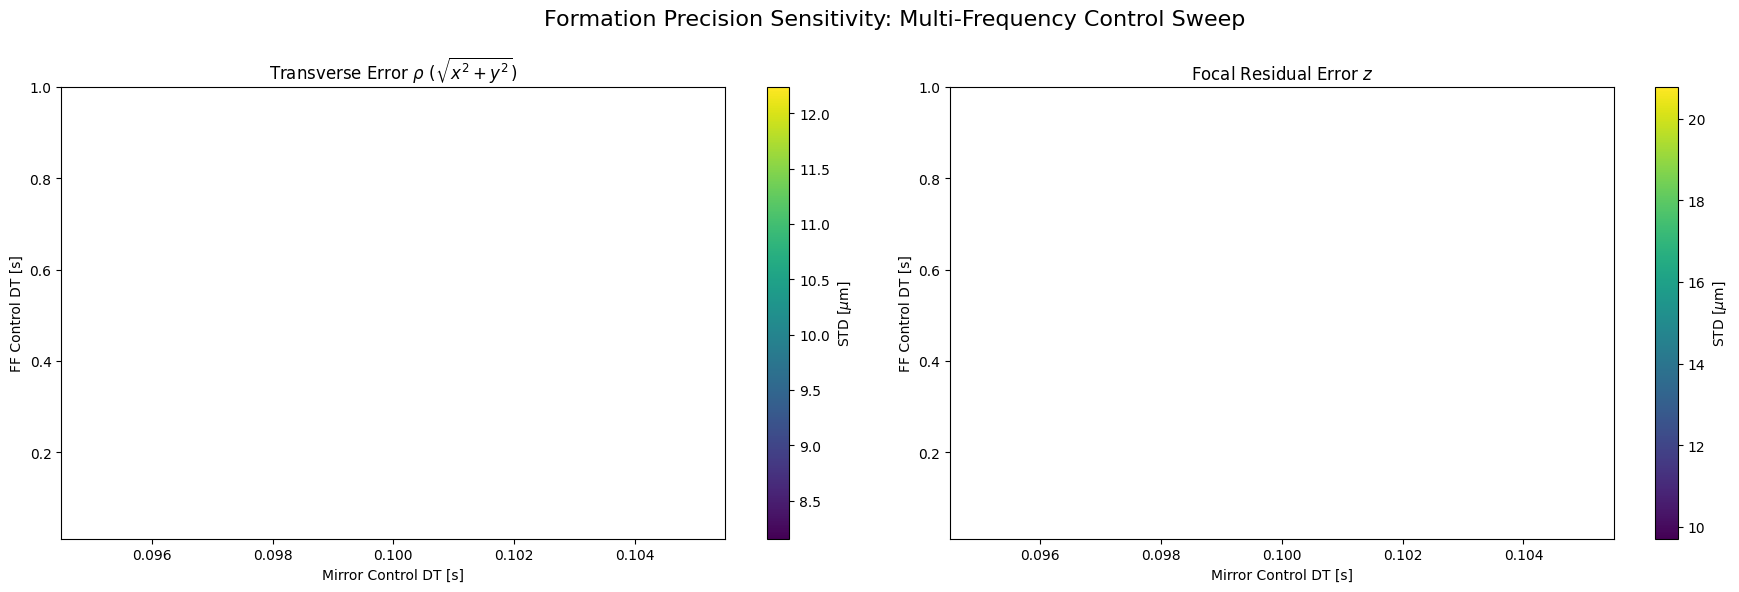

In [6]:
# 1. Round to unify values and find unique axes
ffdt_vals_clean = [round(x, 6) for x in ffdt_vals]
mrdt_vals_clean = [round(x, 6) for x in mrdt_vals]
unique_ffdt = sorted(list(set(ffdt_vals_clean)))
unique_mrdt = sorted(list(set(mrdt_vals_clean)))
print(f'unique ffdt {unique_ffdt}')
print(f'unique mrdt {unique_mrdt}')

# 2. Initialize grids with NaN (so missing points aren't plotted as 0.0)
grid_rho = np.full((len(unique_ffdt), len(unique_mrdt)), np.nan)
grid_z   = np.full((len(unique_ffdt), len(unique_mrdt)), np.nan)
print(f"Plotting {len(ffdt_vals)} runs on a {len(unique_ffdt)}x{len(unique_mrdt)} grid.")

# 3. Populate
focal_const = 5000.0 
count_filled = 0
for i in range(len(ffdt_vals_clean)):
    ffdt = ffdt_vals_clean[i]
    mrdt = mrdt_vals_clean[i]
    
    fine_idx = np.where(phase[i] == 'Fine Observation')[0]
    if len(fine_idx) > 0:
        fine_start, fine_end = full_times[i][fine_idx[0]], full_times[i][fine_idx[-1]]
        fine_mask = (eng_times[i] >= fine_start) & (eng_times[i] <= fine_end)
        fine_rel = rel_pos_B[i][fine_mask]
        
        if len(fine_rel) > 0:
            std_rho = np.std(np.sqrt(fine_rel[:, 0]**2 + fine_rel[:, 1]**2))
            std_z   = np.std(fine_rel[:, 2] - focal_const)
            
            r = unique_ffdt.index(ffdt)
            c = unique_mrdt.index(mrdt)
            
            grid_rho[r, c] = std_rho
            grid_z[r, c]   = std_z
            count_filled += 1
print(f"Nodes successfully filled: {count_filled}")
# 4. Plot 
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Formation Precision Sensitivity: Multi-Frequency Control Sweep', fontsize=16)
coords = [r'Transverse Error $\rho$ ($\sqrt{x^2+y^2}$)', 'Focal Residual Error $z$']
grids  = [grid_rho, grid_z]
for ax, grid, title in zip(axes, grids, coords):
    # 'magma' or 'viridis' work well; 'inferno' is also an option.
    # Bad nodes (NaN) will be transparent/empty.
    im = ax.imshow(grid * 1e6, origin='lower', aspect='auto',
                   extent=[min(unique_mrdt), max(unique_mrdt), min(unique_ffdt), max(unique_ffdt)])
    
    ax.set_title(title)
    ax.set_xlabel('Mirror Control DT [s]')
    ax.set_ylabel('FF Control DT [s]')
    
    # Optional: Scatter the actual data points to show the grid centers
    ax.scatter(mrdt_vals_clean, ffdt_vals_clean, color='white', s=5, alpha=0.3)
    
    cbar = fig.colorbar(im, ax=ax).set_label('STD [$\mu$m]')
plt.tight_layout()
plt.subplots_adjust(top=0.85) 
plt.show()

In [8]:
# 1. CLEANING: Use the rounded dts for clear labeling
ffdt_vals_clean = [round(x, 6) for x in ffdt_vals]
mrdt_vals_clean = [round(x, 6) for x in mrdt_vals]
num_runs = len(ffdt_vals_clean)
# Setup coordinate labels
coord_letter = ['x', 'y', 'z residual']
focal_const = 5000.0
# ─── CYCLE THROUGH EVERY RUN TO CREATE A HIGHLIGHTED PLOT ───
for target_idx in range(num_runs):
    current_ffdt = ffdt_vals_clean[target_idx]
    current_mrdt = mrdt_vals_clean[target_idx]
    
    # 2. Set up the figure and GridSpec 
    fig = plt.figure(figsize=(14, 10))
    gs = gridspec.GridSpec(3, 2, width_ratios=[1, 2], figure=fig)
    fig.suptitle(f'FF dt={current_ffdt:.2f}s\n MR dt={current_mrdt:.2f}s', 
                 fontsize=18)
    
    axes = []
    for row in range(3):
        ax_cal = fig.add_subplot(gs[row, 0])
        ax_fine = fig.add_subplot(gs[row, 1])
        ax_fine.yaxis.tick_right()
        ax_fine.yaxis.set_label_position("right")
        # Build 2D list (using [] instead of ())
        axes.append([ax_cal, ax_fine])
    
    # Labeling
    axes[2][0].set_xlabel('Time Since Calibration [s]')
    axes[2][1].set_xlabel('Time Since Fine Observation [s]')
    for c_idx in range(3):
        axes[c_idx][0].set_ylabel(f'{coord_letter[c_idx]} [$\mu$m]')
        axes[c_idx][1].set_ylabel(f'{coord_letter[c_idx]} [$\mu$m]')
        axes[c_idx][0].grid(True, ls='--', alpha=0.3)
        axes[c_idx][1].grid(True, ls='--', alpha=0.3)
        
    # 3. PLOT ALL RUNS IN THE BACKGROUND (RED)
    for i in range(num_runs):
        is_highlight = (i == target_idx)
        color = 'tab:orange' if is_highlight else 'red'
        lw    = 1.5 if is_highlight else 0.4
        zorder = 10 if is_highlight else 1
        alpha = 1.0 if is_highlight else 1 
        t_eng = eng_times[i]
        rel   = rel_pos_B[i]
        
        cal_idx  = np.where(phase[i] == 'Calibration')[0]
        fine_idx = np.where(phase[i] == 'Fine Observation')[0]
        
        if len(cal_idx) > 0:
            c_mask = (t_eng >= full_times[i][cal_idx[0]]) & (t_eng <= full_times[i][cal_idx[-1]])
            t_slice = t_eng[c_mask] - t_eng[c_mask][0]
            val_slice = rel[c_mask]
            
            for c_idx in range(3):
                vals = (val_slice[:, c_idx] - (focal_const if c_idx==2 else 0)) * 1e6
                axes[c_idx][0].plot(t_slice, vals, color=color, lw=lw, alpha=alpha, zorder=zorder)
        if len(fine_idx) > 0:
            f_mask = (t_eng >= full_times[i][fine_idx[0]]) & (t_eng <= full_times[i][fine_idx[-1]])
            t_slice = t_eng[f_mask] - t_eng[f_mask][0]
            val_slice = rel[f_mask]
            
            for c_idx in range(3):
                vals = (val_slice[:, c_idx] - (focal_const if c_idx==2 else 0)) * 1e6
                axes[c_idx][1].plot(t_slice, vals, color=color, lw=lw, alpha=alpha, zorder=zorder)
                
    # 4. Final Cleanup
    plt.tight_layout()
    # Iterate through nested list to process each axis individually
    for ax_pair in axes:
        for ax in ax_pair:
            utilities.set_dark_transparent(ax=ax)
    
    fig.savefig(f"{path}examination_of_dts/highlight_ff{current_ffdt}_mr{current_mrdt}.png")
    plt.close(fig)